In [5]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_music_dataset.csv")

df.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0


In [6]:
print(df.columns)

Index(['Unnamed: 0', 'artist_name', 'track_name', 'release_date', 'genre',
       'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time',
       'shake the audience', 'family/gospel', 'romantic', 'communication',
       'obscene', 'music', 'movement/places', 'light/visual perceptions',
       'family/spiritual', 'like/girls', 'sadness', 'feelings', 'danceability',
       'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy',
       'topic', 'age'],
      dtype='object')


In [10]:
audio_features = [
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'instrumentalness',
    'loudness'
]

In [11]:
df[audio_features] = df[audio_features].fillna(0)

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(df[audio_features])

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

audio_similarity = cosine_similarity(scaled_features)

/Users/sachintha/Projects/music-recommendation-system/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sachintha/Projects/music-recommendation-system/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sachintha/Projects/music-recommendation-system/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [14]:
def get_audio_recommendations(song_name, df, similarity_matrix):
    
    idx = df[df['track_name'] == song_name].index
    
    if len(idx) == 0:
        print("Song not found")
        return
    
    idx = idx[0]
    
    similarity_scores = list(enumerate(similarity_matrix[idx]))
    
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    similarity_scores = similarity_scores[1:11]
    
    song_indices = [i[0] for i in similarity_scores]
    
    return df.iloc[song_indices][
        ['track_name', 'artist_name', 'genre']
    ]

In [15]:
recommendations = get_audio_recommendations(
    "Cry",
    df,
    audio_similarity
)

recommendations

Song not found


In [17]:
df['popularity_score'] = 1 / (df['age'] + 1)

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['popularity_norm'] = scaler.fit_transform(
    df[['popularity_score']]
)

In [32]:
def smart_recommendations(song_name, df, similarity_matrix):

    idx = df[
        df['track_name'].str.lower() == song_name.lower()
    ].index

    if len(idx) == 0:
        print("Song not found")
        return

    idx = idx[0]

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    scored_songs = []

    for i, score in similarity_scores:

        popularity = df.iloc[i]['popularity_norm']

        final_score = (
            0.8 * score +
            0.2 * popularity
        )

        scored_songs.append((i, final_score))

    scored_songs = sorted(
        scored_songs,
        key=lambda x: x[1],
        reverse=True
    )

    scored_songs = scored_songs[1:11]

    song_indices = [i[0] for i in scored_songs]

    return df.iloc[song_indices][
        [
            'track_name',
            'artist_name',
            'genre'
        ]
    ]

In [27]:
df['popularity_score'] = 1 / (df['age'] + 1)

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['popularity_norm'] = scaler.fit_transform(
    df[['popularity_score']]
)

In [29]:
df['track_name'].head(20)

0                                  mohabbat bhi jhoothi
1                                             i believe
2                                                   cry
3                                              patricia
4                                    apopse eida oneiro
5     round and round (with mitchell ayres and his o...
6                            opm medley: when i met you
7                                it's not for me to say
8                              klapse me mana klapse me
9                                     finito la mouzika
10                         drømmer man om den, vågner..
11                                        carolina moon
12                                       necessary evil
13                                      kanugona galano
14                                          the carioca
15                                         chicken reel
16                                           blue skies
17                                            da

In [33]:
smart_recommendations(
    "Cry",
    df,
    audio_similarity
)

,track_name,artist_name,genre
27409,donna,the lumineers,rock
27289,i can change,lake street dive,rock
12442,psycho,danielle bradbery,country
20838,i fall to pieces,renee olstead,jazz
20892,loving you,cyrille aimee,jazz
20832,love is here to stay,tony bennett,jazz
17008,you won't be satisfied (until you break my heart),ella fitzgerald,blues
16970,"goodnite sweetheart, goodnite",the spaniels,blues
27343,you,a great big world,rock
20771,atoll,nai palm,jazz


In [34]:
def mood_recommendation(df, mood):
    
    if mood == "happy":
        result = df[df['valence'] > 0.7]
        
    elif mood == "sad":
        result = df[df['valence'] < 0.3]
        
    elif mood == "energetic":
        result = df[df['energy'] > 0.7]
        
    elif mood == "calm":
        result = df[df['acousticness'] > 0.7]
        
    else:
        return "Mood not found"
    
    return result[
        ['track_name', 'artist_name', 'genre']
    ].head(10)

In [35]:
mood_recommendation(df, "happy")

,track_name,artist_name,genre
3,patricia,pérez prado,pop
5,round and round (with mitchell ayres and his o...,perry como,pop
9,finito la mouzika,stélios kazantzídis,pop
14,the carioca,les paul,pop
15,chicken reel,les paul,pop
19,awaz deta hai sola ka din,asha bhosle,pop
22,ee jagamantha natika,ghantasala,pop
25,paas nahin aaiye haath na lagaiye,lata mangeshkar,pop
26,main na janoon,lata mangeshkar,pop
27,gullyachi shapath,asha bhosle,pop


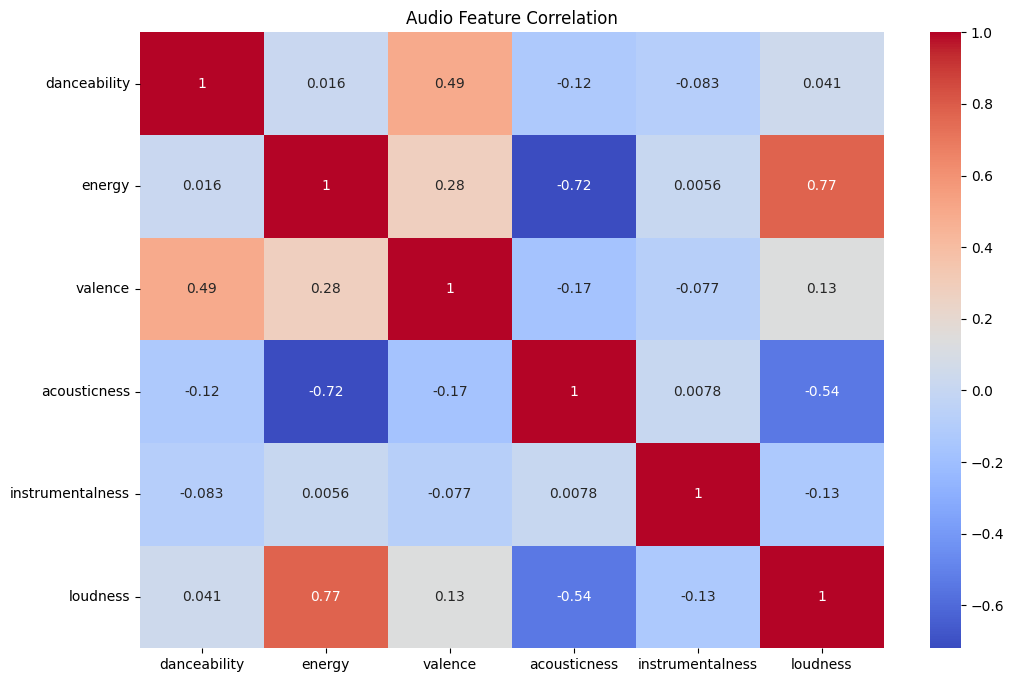

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[audio_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Audio Feature Correlation")

plt.show()

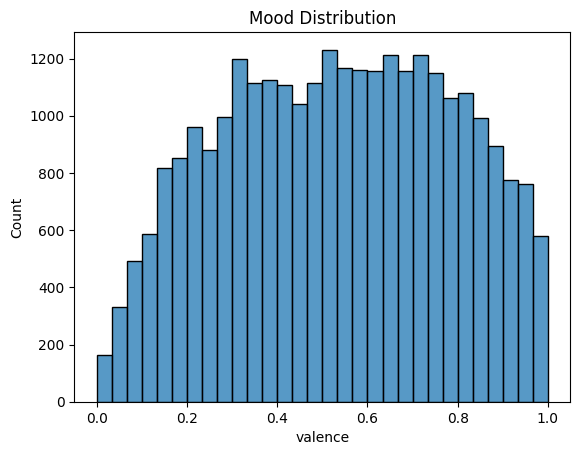

In [37]:
sns.histplot(df['valence'], bins=30)

plt.title("Mood Distribution")

plt.show()

In [38]:
plt.savefig("../outputs/figures/heatmap.png")

<Figure size 640x480 with 0 Axes>

In [39]:
plt.savefig("../outputs/figures/mood_distribution.png")

<Figure size 640x480 with 0 Axes>

In [40]:
df.to_csv("../data/enhanced_music.csv", index=False)